### LangGraph

LangGraph is a framework built on top of LangChain for developing stateful, multi-step AI agents using a graph-based workflow. It enables developers to manage conversation state, memory, decision-making, tool execution, loops, branching, and human-in-the-loop interactions in a structured and reliable manner.

maintains the state of execution

Graph

A graph is a collection of nodes connected by edges, where each node represents a task and each edge defines the flow of execution between tasks.

Node

A node is an individual unit of execution in a LangGraph workflow, such as an LLM call, tool invocation, or custom Python function.

Edge

An edge defines the transition from one node to another, determining the order and conditions under which tasks are executed.

Final Mental Model

Think of the relationship like this:

               Python
                  │
                  ▼
            LangChain
        (AI building blocks)
                  │
                  ▼
            LangGraph
     (AI workflow engine)
                  │
                  ▼
        Production AI Agents
Python gives you the programming language.
LangChain gives you components like models, prompts, tools, and memory.
LangGraph tells those components how to work together in a structured workflow with state, branching, retries, loops, and persistence.


In [2]:
### Building a basic chatbot with langgraph
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages




to solve complex form of workflows we either use 
1) Graph API
2) Functional API


the 3rd component of LandGraph is 
States - saving the values inside  this state variable so that any node in the workflow can access it and use them thats why this is called as  stategraph and it maintains the state fo the workflow.


In [3]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

add_messages this is basically  a reducer that doesn't change the  list it only appends the next line in it and also keeps it constant throught the context

In [4]:
graph_builder

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="qwen/qwen3-32b")

In [7]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000285901FE7D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000285901FEDA0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
llm = init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002858D57A8F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000028590370C40>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [9]:
### CHatbot is also like a node so for every node w ehave to create a node definition
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [10]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)### 2nd parameter is about node implementation
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

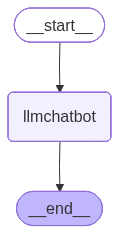

'\n The try block is used to execute code that may raise an exception (error).\n\nExample\n\ntry:\n    print(10/0)\n\nThis would normally crash the program because division by zero is not allowed.\n\nUsing try, Python catches the error instead of stopping the program. \n'

In [11]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

#### display() is a Jupyter function used to render Python objects such as images, tables, HTML, graphs, and Markdown inside the notebook.
"""
 The try block is used to execute code that may raise an exception (error).

Example

try:
    print(10/0)

This would normally crash the program because division by zero is not allowed.

Using try, Python catches the error instead of stopping the program. 
"""

In [12]:

response=graph.invoke({"messages":"Hi"})

In [13]:
response["messages"][-1].content

'<think>\nOkay, the user said "Hi". I need to respond appropriately. Since it\'s a greeting, I should greet them back and offer assistance. Let me make sure the response is friendly and open-ended. Maybe ask how I can help them today. Keep it simple and welcoming.\n</think>\n\nHello! How can I assist you today? 😊'

In [14]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user is asking "Hi How are you?" which is a casual greeting. I need to respond in a friendly and approachable manner. Since I don't have feelings, I should clarify that but still keep the tone positive. Maybe start with a cheerful acknowledgment, then explain my nature, and invite them to ask questions or share what's on their mind. Keep it concise but open-ended to encourage further conversation. Avoid any markdown and use natural, conversational language.
</think>

Hello! I'm here and ready to chat! 😊 While I don't experience feelings in the way humans do, I'm always excited to help with whatever's on your mind. How can I assist you today?


### ChatBot with tools

In [15]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the navigat

In [16]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [17]:
tools=[tool,multiply]

In [18]:
llm_with_tool=llm.bind_tools(tools)

In [19]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002858D57A8F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000028590370C40>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for com

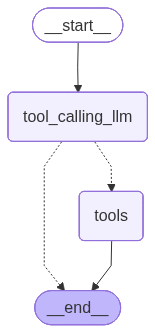

In [20]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [22]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2026/07/01/neocloud-together-ai-raises-800m-leaps-to-8-3b-valuation/", "title": "Neocloud Together AI raises $800M, leaps to $8.3B valuation - TechCrunch", "score": 0.72977066, "published_date": "Wed, 01 Jul 2026 18:29:14 GMT", "content": "That means that neoclouds, which are the companies providing AI-specific hardware (often Nvidia GPU clusters) and other infrastructure tools, have been hot commodities for VC investment. Upscale AI raised a Series A plus an A extension totaling $500 million at a $2 billion valuation last month; TensorWave — which focuses on GPU clusters from AMD — raised a $350 million Series B at $1.55 billion valuation last month as well, to name just two recent examples.\\n\\nTogether AI was co-founded by Vipul Ved Prakash (pictured above, middle) after he sold his previous startup, social media search platform Topsy, to Apple in 2013

In [23]:
for m in response["messages"]:
    m.pretty_print()


================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (j1tfw0cwx)
 Call ID: j1tfw0cwx
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2026/07/01/neocloud-together-ai-raises-800m-leaps-to-8-3b-valuation/", "title": "Neocloud Together AI raises $800M, leaps to $8.3B valuation - TechCrunch", "score": 0.72977066, "published_date": "Wed, 01 Jul 2026 18:29:14 GMT", "content": "That means that neoclouds, which are the companies providing AI-specific hardware (often Nvidia GPU clusters) and other infrastructure tools, have been hot commodities for VC inve

In [24]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (73eyh6kkv)
 Call ID: 73eyh6kkv
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


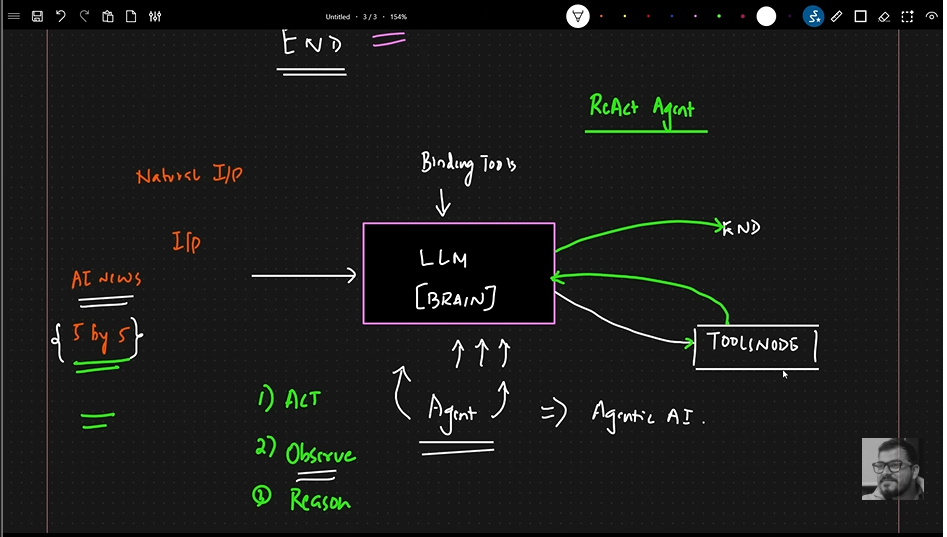

### ReAct agent architecture


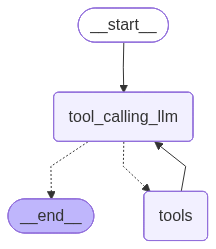

In [25]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
response=graph.invoke({"messages":"What is 5 multiplied by 2 and also give me the latest AI news"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2 and also give me the latest AI news
================================== Ai Message ==================================
Tool Calls:
  multiply (mbhtfg11p)
 Call ID: mbhtfg11p
  Args:
    a: 5
    b: 2
  tavily_search (9sw7kxen2)
 Call ID: 9sw7kxen2
  Args:
    query: latest AI news
    time_range: day
    topic: general
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://play.google.com/store/apps/details?id=ro.jubu.ainews&hl=en_US", "title": "AI News - Apps on Google Play", "content": "AINews is the focused, beautifully designed AI news reader. Get the latest from 60+ top AI sources, then learn, create, translate and pla

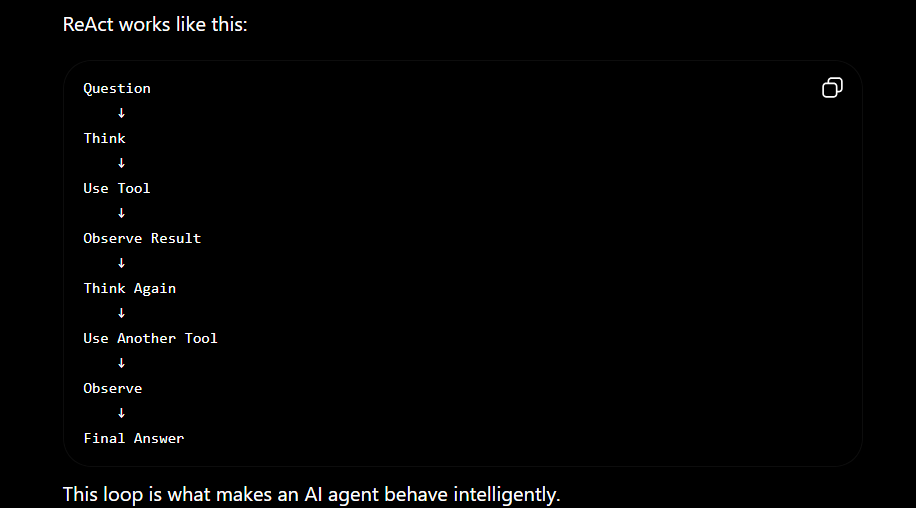

### Adding Memory in the Agentic Graph

In [27]:
response=graph.invoke({"messages":"hello my name is Aryendra"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

hello my name is Aryendra
================================== Ai Message ==================================

Hello Aryendra! 👋 How can I assist you today? Feel free to ask me any questions or let me know if you need help with anything specific.


In [28]:
response=graph.invoke({"messages":"What is my name"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't know your name. Could you please tell me your name?


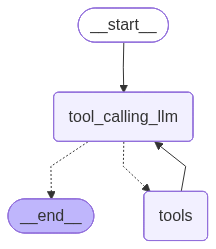

In [29]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
### Cretae a thread id for memory
config = {"configurable":{"thread_id":"1"}}
response  = graph.invoke({"messages" : " Hi my name is Aryendra"},config=config)
response

{'messages': [HumanMessage(content=' Hi my name is Aryendra', additional_kwargs={}, response_metadata={}, id='7de83246-d4cc-4625-8085-1a7c05a845c0'),
  AIMessage(content='Hello Aryendra! How can I assist you today?', additional_kwargs={'reasoning_content': "Okay, the user introduced themselves as Aryendra. I need to respond appropriately. Since there's no specific question or request in their message, I should just acknowledge their greeting and offer assistance. Let me check the tools provided to see if any are needed here. The tools include a search function and a multiply function. But since the user didn't ask anything that requires those tools, a simple response is best. I'll say hello and ask how I can help them today.\n"}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 1787, 'total_tokens': 1898, 'completion_time': 0.20630504, 'completion_tokens_details': {'reasoning_tokens': 95}, 'prompt_time': 0.08272645, 'prompt_tokens_details': None, 'queue_tim

In [31]:
response["messages"][-1].content

'Hello Aryendra! How can I assist you today?'

In [32]:
response=graph.invoke({"messages":"What is my name"},config=config)

response

{'messages': [HumanMessage(content=' Hi my name is Aryendra', additional_kwargs={}, response_metadata={}, id='7de83246-d4cc-4625-8085-1a7c05a845c0'),
  AIMessage(content='Hello Aryendra! How can I assist you today?', additional_kwargs={'reasoning_content': "Okay, the user introduced themselves as Aryendra. I need to respond appropriately. Since there's no specific question or request in their message, I should just acknowledge their greeting and offer assistance. Let me check the tools provided to see if any are needed here. The tools include a search function and a multiply function. But since the user didn't ask anything that requires those tools, a simple response is best. I'll say hello and ask how I can help them today.\n"}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 1787, 'total_tokens': 1898, 'completion_time': 0.20630504, 'completion_tokens_details': {'reasoning_tokens': 95}, 'prompt_time': 0.08272645, 'prompt_tokens_details': None, 'queue_tim

In [33]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)
response

{'messages': [HumanMessage(content=' Hi my name is Aryendra', additional_kwargs={}, response_metadata={}, id='7de83246-d4cc-4625-8085-1a7c05a845c0'),
  AIMessage(content='Hello Aryendra! How can I assist you today?', additional_kwargs={'reasoning_content': "Okay, the user introduced themselves as Aryendra. I need to respond appropriately. Since there's no specific question or request in their message, I should just acknowledge their greeting and offer assistance. Let me check the tools provided to see if any are needed here. The tools include a search function and a multiply function. But since the user didn't ask anything that requires those tools, a simple response is best. I'll say hello and ask how I can help them today.\n"}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 1787, 'total_tokens': 1898, 'completion_time': 0.20630504, 'completion_tokens_details': {'reasoning_tokens': 95}, 'prompt_time': 0.08272645, 'prompt_tokens_details': None, 'queue_tim

### Streaming

In [34]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [35]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

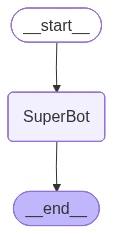

In [36]:
graph = StateGraph(State)
## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [37]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='e0631c42-030c-42d9-bf9d-99eb27fb4190'),
  AIMessage(content="<think>\nOkay, the user is Krish and he likes cricket. Let me think about how to respond.\n\nFirst, I should acknowledge his name and his interest. Maybe ask about his favorite team or player to keep the conversation going.\n\nI know cricket is popular in countries like India, Pakistan, Australia, etc. He might be from one of those places. Maybe ask where he's from?\n\nAlso, what does he like most about cricket? The strategy, the players, the excitement of the game?\n\nI should keep the tone friendly and open, encouraging him to share more. Maybe mention some current events in cricket if I know any, but I should check if it's up to date.\n\nWait, the current date is October 2023. There was the T20 World Cup in June 2023, won by England. Maybe that's relevant.\n\nBut I shouldn't assume he's interested in

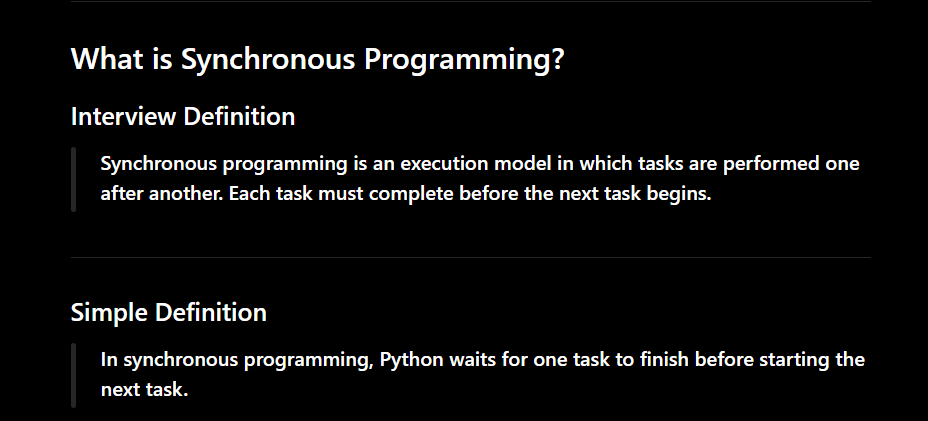

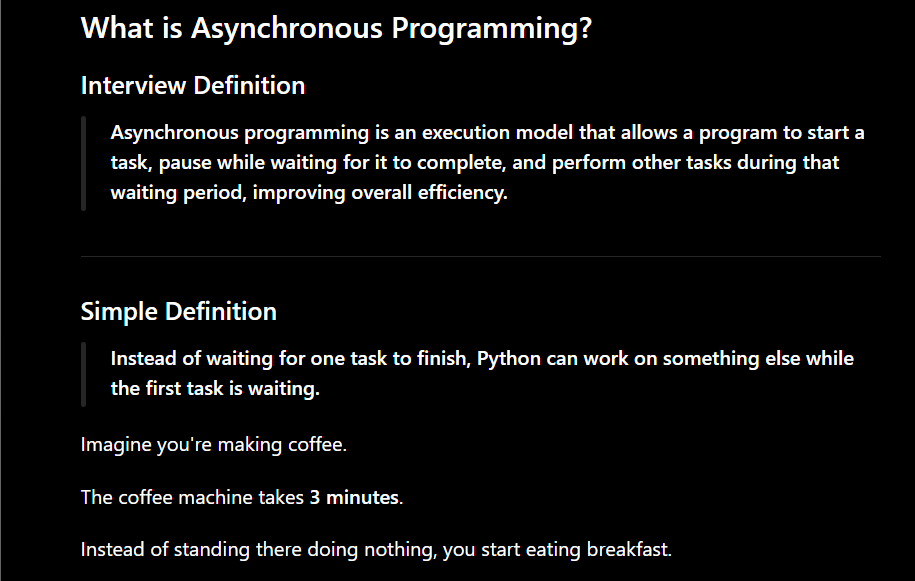


### Streaming
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

1) values : This streams the full state of the graph after each node is called.
2) updates : This streams updates to the state of the graph after each node is called.

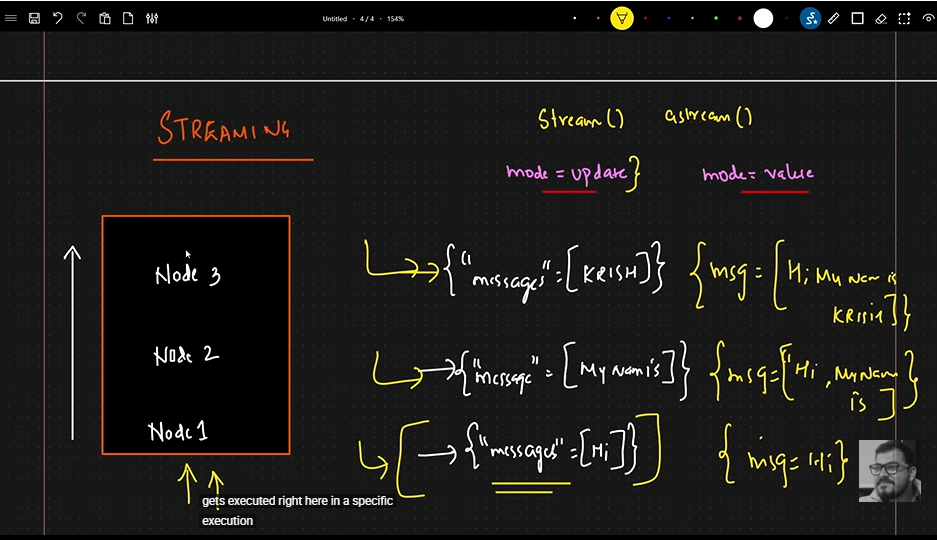

In [41]:
config = {"configurable": {"thread_id": "3"}}
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)



{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, Krish has mentioned his name and his love for cricket three times now. Each time, I responded with enthusiasm and tried to engage him further by asking specific questions. But he keeps replying with the same message. Maybe he's testing the system or there's an issue with his input. Let me think about possible reasons.\n\nFirst, maybe he's not getting a response he expects. Even though I'm responding, he might be looking for something different. Alternatively, he could be using the chatbot to collect responses for some purpose, like a project or a class assignment. Another possibility is that he's not comfortable providing more information or there's a language barrier.\n\nI should consider his possible intent. If he's a student, maybe he needs help with cricket-related topics. If he's just a fan, he might want to discuss the latest news or upcoming matches. Since he hasn't provided additional details, I should prompt him agai

In [42]:
config = {"configurable": {"thread_id": "3"}}
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)



{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='d1a3c823-3592-464f-a8d5-50294593346f'), AIMessage(content="<think>\nOkay, the user introduced themselves as Krish and mentioned they like cricket. Let me start by greeting them warmly. I should acknowledge their name and show genuine interest in their hobby.\n\nFirst, I'll thank them for sharing their name and hobby. Then, I want to engage them by asking about their favorite aspects of cricket. It's important to be open-ended to encourage a detailed response. Maybe ask if they play the game or just follow it. Also, inquiring about their favorite teams or players could help build rapport and keep the conversation going.\n\nI need to make sure my response is friendly and not too formal. Using emojis might make it feel more approachable. Let me structure the response to be welcoming, ask questions, and express eagerness to help with anything else. That way, Krish fe